# Geo-Nexus v3.2 — P3 OSCD Supervised Transfer

This notebook is the final audited P3 transfer notebook. It starts from the completed Geo-Nexus DAPT encoder and trains the new LKA decoder on the frozen 11/3/10 OSCD split.

### Frozen protocol
- OSCD official train cities: 14
- Geo-Nexus validation cities: `rennes`, `saclay_e`, `beirut`
- Geo-Nexus training cities: remaining 11 official train cities
- Official test cities: 10, untouched until final evaluation
- Patch size: `128 × 128`
- Train stride: `64`
- Validation/test stride: `128`
- Input tensor: `[2, 17, 128, 128]`
- Optical channels: 11 Sentinel-2 bands + NDVI + NDBI
- SAR placeholders: VV/VH/cross-ratio = zeros
- Quality channel: `q = 1`
- Train sampler: patches with `change_fraction > 1%` repeated `3×`; validation/test are never oversampled

### P3 transfer path
`SSL4EO optical encoder → Maharashtra DAPT encoder → new LKA decoder → OSCD supervised training`

During P3, the SAR encoder and quality gate are frozen, the gate is forced to `optical_only` (`g = 1`), and the new LKA decoder is trainable. The architecture specifies 80 epochs, batch 32, encoder LR `1e-5`, decoder LR `1e-4`, BCE/Dice `0.5/0.5`, positive-class weight `8.0`, deep supervision `[1.0, 0.5, 0.25]`, and early stopping patience 15 monitored on validation F1.

The notebook validates the staged OSCD tensors, labels, city metadata and sampler sequence before any model training. It tolerates an older sampler JSON that omits descriptive metadata fields, but only when the actual sampler sequence still exactly matches the frozen 1% threshold and 3× positive oversampling protocol.

The notebook also hard-checks the DAPT encoder state: both optical and SAR DAPT branches must be present. The OSCD model smoke gate checks tensor shapes and a finite backward pass before training starts.


## Inputs this notebook expects on Kaggle

Attach these datasets under **Add Input**:

1. `sumit07125/oscd-onera-v1`
2. `sumit07125/geonexus-v3-2-dapt-6664-artifacts`
3. `sumit07125/geonexus-mh-v3` (used only to obtain the train-only normalization statistics)

The notebook **does not assume their mounted directory names**. It discovers files by filename/content and fails with a precise message if a required artifact is missing.


In [1]:
# ============================================================
# CELL 1 — runtime, imports, configuration
# ============================================================

from pathlib import Path
import os, sys, json, math, time, shutil, zipfile, hashlib, csv, gc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18
import matplotlib.pyplot as plt

SEED = 20260921
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("GPU is required for P3 OSCD training. In Kaggle, select a GPU accelerator and rerun this notebook.")

DEVICE = torch.device("cuda")
PATCH = 128
INPUT_CH = 17
EPOCHS = 80
BATCH_SIZE = 32
LR_ENCODER = 1e-5
LR_DECODER = 1e-4
POS_WEIGHT = 8.0
WEIGHT_DECAY = 0.05  # project optimizer default; P3 architecture fixes the LRs but does not separately lock a P3 WD
EARLY_STOP_PATIENCE = 15
TRAIN_POS_THRESHOLD = 0.01
RUN_SCHEMA_VERSION = "p3-v3.2-final-2026-09-21-r2"
P3_GATE_LOSS_WEIGHT = 0.0  # P3 is optical-only; the gate is frozen and g=1.

TRAIN_CITIES = [
    "abudhabi","aguasclaras","beihai","bercy","bordeaux",
    "cupertino","hongkong","mumbai","nantes","paris","pisa"
]
VAL_CITIES = ["rennes", "saclay_e", "beirut"]
TEST_CITIES = [
    "brasilia","chongqing","dubai","lasvegas","milano",
    "montpellier","norcia","rio","saclay_w","valencia"
]
EXPECTED_SHAPES = {
    "train": (860, 2, 17, 128, 128),
    "val": (100, 2, 17, 128, 128),
    "test": (146, 2, 17, 128, 128),
}

RUN_DIR = Path("/kaggle/working/geonexus_p3_oscd")
RUN_DIR.mkdir(parents=True, exist_ok=True)
LATEST_CKPT = RUN_DIR / "geonexus_v3_2_p3_oscd_latest.pth"
BEST_CKPT = RUN_DIR / "geonexus_v3_2_p3_oscd_best.pth"
HISTORY_JSON = RUN_DIR / "p3_oscd_history.json"
CONFIG_JSON = RUN_DIR / "p3_oscd_config.json"
MODEL_PY = RUN_DIR / "p3_geonexus_model.py"
CURVE_PNG = RUN_DIR / "p3_oscd_training_curves.png"
VAL_SWEEP_JSON = RUN_DIR / "p3_oscd_val_threshold_sweep.json"
TEST_METRICS_JSON = RUN_DIR / "p3_oscd_test_metrics.json"
TEST_SCENE_CSV = RUN_DIR / "p3_oscd_test_per_scene.csv"
FINAL_MODEL = RUN_DIR / "geonexus_v3_2_p3_oscd_model.pth"
FINAL_STATE = RUN_DIR / "geonexus_v3_2_p3_oscd_state_dict.pt"
SHA256_JSON = RUN_DIR / "SHA256SUMS.json"

print("Geo-Nexus v3.2 — P3 OSCD Supervised Transfer")
print("=" * 78)
print("Device:", DEVICE)
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
print("PyTorch:", torch.__version__)
print("Torchvision:", __import__('torchvision').__version__)
print("Run directory:", RUN_DIR)
print("Notebook revision:", RUN_SCHEMA_VERSION)


Geo-Nexus v3.2 — P3 OSCD Supervised Transfer
Device: cuda
GPU 0: Tesla T4
GPU 1: Tesla T4
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
Run directory: /kaggle/working/geonexus_p3_oscd
Notebook revision: p3-v3.2-final-2026-09-21-r2


In [2]:
# ============================================================
# CELL 2 — robust input discovery (validated frozen dataset contract)
# ============================================================

KAGGLE_INPUT = Path("/kaggle/input")
if not KAGGLE_INPUT.exists():
    raise RuntimeError(
        "/kaggle/input does not exist. This notebook is intended for a Kaggle runtime."
    )


def find_named_file(filename, roots=(KAGGLE_INPUT, RUN_DIR)):
    hits = []
    for root in roots:
        if not root.exists():
            continue
        for p in root.rglob(filename):
            if p.is_file():
                hits.append(p)
    # Stable, deterministic order.
    return sorted(set(hits), key=lambda p: str(p))


OSCD_CORE_FILES = [
    "oscd_train.npy", "oscd_train_label.npy", "oscd_train_meta.json",
    "oscd_val.npy", "oscd_val_label.npy", "oscd_val_meta.json",
    "oscd_test.npy", "oscd_test_label.npy", "oscd_test_meta.json",
    "oscd_train_sampler.json",
]

OPTIONAL_OSCD_PROVENANCE = (
    "oscd_splits.json",
    "oscd_dataset_manifest.json",
    "oscd_preprocess_manifest.json",
    "README.md",
    "dataset-metadata.json",
)


def _validate_oscd_candidate(root):
    """Validate a candidate root using headers/metadata only; no large RAM load."""
    expected = EXPECTED_SHAPES

    for split, shape in expected.items():
        xp = root / f"oscd_{split}.npy"
        yp = root / f"oscd_{split}_label.npy"
        if not xp.is_file() or not yp.is_file():
            return False
        x = np.load(xp, mmap_mode="r")
        y = np.load(yp, mmap_mode="r")
        if tuple(x.shape) != shape or x.dtype != np.int16:
            return False
        if tuple(y.shape) != (shape[0], PATCH, PATCH) or y.dtype != np.uint8:
            return False

    try:
        with open(root / "oscd_train_meta.json", encoding="utf-8") as f:
            train_meta = json.load(f)
        with open(root / "oscd_val_meta.json", encoding="utf-8") as f:
            val_meta = json.load(f)
        with open(root / "oscd_test_meta.json", encoding="utf-8") as f:
            test_meta = json.load(f)
    except Exception:
        return False

    if len(train_meta) != EXPECTED_SHAPES["train"][0]:
        return False
    if len(val_meta) != EXPECTED_SHAPES["val"][0]:
        return False
    if len(test_meta) != EXPECTED_SHAPES["test"][0]:
        return False

    if {m.get("city") for m in train_meta} != set(TRAIN_CITIES):
        return False
    if {m.get("city") for m in val_meta} != set(VAL_CITIES):
        return False
    if {m.get("city") for m in test_meta} != set(TEST_CITIES):
        return False

    return True


def find_dataset_root(required_files):
    candidates = []
    first = required_files[0]
    for p in KAGGLE_INPUT.rglob(first):
        if not p.is_file():
            continue
        root = p.parent
        if all((root / f).is_file() for f in required_files):
            if _validate_oscd_candidate(root):
                candidates.append(root)

    unique = []
    seen = set()
    for p in candidates:
        rp = str(p.resolve())
        if rp not in seen:
            seen.add(rp)
            unique.append(p)

    if not unique:
        raise FileNotFoundError(
            "Could not find a VALID prepared OSCD root. The attached dataset must "
            "contain the frozen 860/100/146 tensors, labels, metadata, and sampler."
        )

    def ranking_key(root):
        optional_score = sum(int((root / name).is_file()) for name in OPTIONAL_OSCD_PROVENANCE)
        bytes_core = sum((root / f).stat().st_size for f in required_files)
        return (optional_score, bytes_core)

    unique.sort(key=ranking_key, reverse=True)
    if len(unique) > 1:
        print("Multiple VALID OSCD roots found; selecting the highest-ranked root:")
        for candidate in unique:
            print(
                "  -", candidate,
                "optional_provenance_files=",
                sum(int((candidate / name).is_file()) for name in OPTIONAL_OSCD_PROVENANCE),
            )

    return unique[0]


OSCD_ROOT = find_dataset_root(OSCD_CORE_FILES)

SPLIT_MANIFEST_PATH = OSCD_ROOT / "oscd_splits.json"
PREP_MANIFEST_PATH = OSCD_ROOT / "oscd_preprocess_manifest.json"


def find_norm_stats_root():
    required = {
        "norm_stats_trainonly.json",
        "pune_train.npy",
        "satara_train.npy",
        "pune_meta.json",
        "satara_meta.json",
    }
    roots = []
    for p in KAGGLE_INPUT.rglob("norm_stats_trainonly.json"):
        root = p.parent
        if all((root / name).is_file() for name in required):
            try:
                with open(root / "norm_stats_trainonly.json", encoding="utf-8") as f:
                    stats = json.load(f)
                if (
                    len(stats.get("mean", [])) == INPUT_CH
                    and len(stats.get("std", [])) == INPUT_CH
                    and list(stats.get("sar_channels", [])) == [13, 14, 15]
                ):
                    roots.append(root)
            except Exception:
                continue
    unique = sorted(set(roots), key=lambda r: str(r))
    if not unique:
        return None
    unique.sort(
        key=lambda r: sum((r / name).stat().st_size for name in required),
        reverse=True,
    )
    return unique[0]


NORM_ROOT = find_norm_stats_root()
if NORM_ROOT is None:
    raise FileNotFoundError(
        "Could not find the Geo-Nexus Maharashtra DAPT dataset root containing "
        "the train-only normalization statistics and Pune/Satara training files. "
        "Attach sumit07125/geonexus-mh-v3."
    )
NORM_PATH = NORM_ROOT / "norm_stats_trainonly.json"

DAPT_FINAL_HITS = find_named_file("geonexus_v3_2_dapt_6664_encoder_final.pth")
DAPT_STATE_HITS = find_named_file("geonexus_v3_2_dapt_6664_encoder_state_dict.pt")

ARTIFACT_DIR = RUN_DIR / "dapt_artifact_extract"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

if not DAPT_FINAL_HITS and not DAPT_STATE_HITS:
    for z in sorted(KAGGLE_INPUT.rglob("models.zip"), key=lambda p: str(p)):
        try:
            with zipfile.ZipFile(z) as zz:
                names = set(zz.namelist())
                chosen = [
                    n for n in names
                    if Path(n).name in {
                        "geonexus_v3_2_dapt_6664_encoder_final.pth",
                        "geonexus_v3_2_dapt_6664_encoder_state_dict.pt",
                    }
                ]
                if chosen:
                    zz.extractall(ARTIFACT_DIR)
                    break
        except (zipfile.BadZipFile, OSError):
            continue

    DAPT_FINAL_HITS = find_named_file(
        "geonexus_v3_2_dapt_6664_encoder_final.pth",
        roots=(ARTIFACT_DIR, KAGGLE_INPUT, RUN_DIR),
    )
    DAPT_STATE_HITS = find_named_file(
        "geonexus_v3_2_dapt_6664_encoder_state_dict.pt",
        roots=(ARTIFACT_DIR, KAGGLE_INPUT, RUN_DIR),
    )

DAPT_ENCODER_PATH = (
    DAPT_STATE_HITS[0]
    if DAPT_STATE_HITS
    else (DAPT_FINAL_HITS[0] if DAPT_FINAL_HITS else None)
)
if DAPT_ENCODER_PATH is None:
    raise FileNotFoundError(
        "Could not find the completed DAPT encoder artifact. Attach "
        "sumit07125/geonexus-v3-2-dapt-6664-artifacts and ensure the final "
        "encoder file or models.zip is present."
    )

print("=" * 78)
print("INPUT DISCOVERY")
print("=" * 78)
print("OSCD root        :", OSCD_ROOT)
print("DAPT data root   :", NORM_ROOT)
print("Normalization    :", NORM_PATH)
print("DAPT encoder     :", DAPT_ENCODER_PATH)
print("Optional split manifest:", "FOUND" if SPLIT_MANIFEST_PATH.is_file() else "not present")
print("Optional prep manifest  :", "FOUND" if PREP_MANIFEST_PATH.is_file() else "not present")
print(
    "DAPT artifact kind:",
    "pure state_dict" if Path(DAPT_ENCODER_PATH).name.endswith("state_dict.pt")
    else "wrapped encoder checkpoint",
)


INPUT DISCOVERY
OSCD root        : /kaggle/input/datasets/sumit07125/oscd-onera-v1
DAPT data root   : /kaggle/input/datasets/sumit07125/geonexus-mh-v3
Normalization    : /kaggle/input/datasets/sumit07125/geonexus-mh-v3/norm_stats_trainonly.json
DAPT encoder     : /kaggle/input/datasets/sumit07125/geonexus-v3-2-dapt-6664-artifacts/models/geonexus_v3_2_dapt_6664_encoder_state_dict.pt
Optional split manifest: not present
Optional prep manifest  : FOUND
DAPT artifact kind: pure state_dict


In [3]:
# ============================================================
# CELL 3 — hard-gate OSCD dataset, split and sampler
# ============================================================

for split, expected in EXPECTED_SHAPES.items():
    x = np.load(OSCD_ROOT / f"oscd_{split}.npy", mmap_mode="r")
    y = np.load(OSCD_ROOT / f"oscd_{split}_label.npy", mmap_mode="r")

    assert tuple(x.shape) == expected, (split, x.shape, expected)
    assert x.dtype == np.int16, (split, x.dtype)
    assert tuple(y.shape) == (expected[0], PATCH, PATCH), (split, y.shape)
    assert y.dtype == np.uint8, (split, y.dtype)

    # Labels are only ~20 MB total, so check all label values rather than
    # validating only the first few patches.
    unique_labels = np.unique(y)
    assert set(unique_labels.tolist()) <= {0, 1}, (split, unique_labels)
    del x, y, unique_labels

with open(OSCD_ROOT / "oscd_train_meta.json", encoding="utf-8") as f:
    train_meta = json.load(f)
with open(OSCD_ROOT / "oscd_val_meta.json", encoding="utf-8") as f:
    val_meta = json.load(f)
with open(OSCD_ROOT / "oscd_test_meta.json", encoding="utf-8") as f:
    test_meta = json.load(f)
with open(OSCD_ROOT / "oscd_train_sampler.json", encoding="utf-8") as f:
    sampler_meta = json.load(f)

assert len(train_meta) == 860
assert len(val_meta) == 100
assert len(test_meta) == 146
assert set(m["city"] for m in train_meta) == set(TRAIN_CITIES)
assert set(m["city"] for m in val_meta) == set(VAL_CITIES)
assert set(m["city"] for m in test_meta) == set(TEST_CITIES)
assert set(TRAIN_CITIES).isdisjoint(VAL_CITIES)
assert set(TRAIN_CITIES).isdisjoint(TEST_CITIES)
assert set(VAL_CITIES).isdisjoint(TEST_CITIES)

# The current prepared sampler schema includes these descriptive fields.
# Older versions of the same prepared dataset may omit them. In that case
# the frozen Geo-Nexus protocol supplies the values, and the actual
# sample_index sequence is still verified exactly below. This avoids a
# false failure on metadata-only schema drift without weakening the sampler gate.
sampler_threshold = float(sampler_meta.get("positive_threshold", TRAIN_POS_THRESHOLD))
sampler_oversample = int(sampler_meta.get("oversample_factor", 3))
sampler_scope = str(sampler_meta.get("scope", "TRAIN ONLY"))

assert sampler_threshold == TRAIN_POS_THRESHOLD, sampler_threshold
assert sampler_oversample == 3, sampler_oversample
assert sampler_scope == "TRAIN ONLY", sampler_scope

train_indices = list(map(int, sampler_meta["sample_index"]))
pos = [i for i, m in enumerate(train_meta) if m["chg_frac"] > TRAIN_POS_THRESHOLD]
neg = [i for i, m in enumerate(train_meta) if m["chg_frac"] <= TRAIN_POS_THRESHOLD]

# This is the authoritative sampler check: exactly the positive patches
# repeated 3x, followed by the negatives, matching the frozen preparation.
assert train_indices == pos * 3 + neg
assert len(train_indices) == len(pos) * 3 + len(neg)

sampler_n_pos = int(sampler_meta.get("n_pos", len(pos)))
sampler_n_neg = int(sampler_meta.get("n_neg", len(neg)))
assert sampler_n_pos == len(pos), (sampler_n_pos, len(pos))
assert sampler_n_neg == len(neg), (sampler_n_neg, len(neg))

steps_per_epoch = len(train_indices) // BATCH_SIZE
assert len(train_indices) == 1694, len(train_indices)
assert steps_per_epoch == 52, steps_per_epoch

missing_descriptive = [
    k for k in ("positive_threshold", "oversample_factor", "scope")
    if k not in sampler_meta
]

print("=" * 78)
print("OSCD DATASET GATES: PASS")
print("=" * 78)
print("train shape :", EXPECTED_SHAPES["train"])
print("val shape   :", EXPECTED_SHAPES["val"])
print("test shape  :", EXPECTED_SHAPES["test"])
print("train cities:", TRAIN_CITIES)
print("val cities  :", VAL_CITIES)
print("test cities :", TEST_CITIES)
print("positive patches (>1%) :", len(pos))
print("negative patches       :", len(neg))
print("oversampled train size :", len(train_indices))
print("steps / epoch (drop_last=True):", steps_per_epoch)
if missing_descriptive:
    print(
        "Sampler metadata compatibility: descriptive fields missing in the attached "
        "sampler; frozen protocol values were inferred and the exact sample_index "
        "sequence passed verification."
    )


OSCD DATASET GATES: PASS
train shape : (860, 2, 17, 128, 128)
val shape   : (100, 2, 17, 128, 128)
test shape  : (146, 2, 17, 128, 128)
train cities: ['abudhabi', 'aguasclaras', 'beihai', 'bercy', 'bordeaux', 'cupertino', 'hongkong', 'mumbai', 'nantes', 'paris', 'pisa']
val cities  : ['rennes', 'saclay_e', 'beirut']
test cities : ['brasilia', 'chongqing', 'dubai', 'lasvegas', 'milano', 'montpellier', 'norcia', 'rio', 'saclay_w', 'valencia']
positive patches (>1%) : 417
negative patches       : 443
oversampled train size : 1694
steps / epoch (drop_last=True): 52
Sampler metadata compatibility: descriptive fields missing in the attached sampler; frozen protocol values were inferred and the exact sample_index sequence passed verification.


In [4]:
# ============================================================
# CELL 4 — source-locked Geo-Nexus P3 model implementation
# ============================================================

source = r"""
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18

CH_RAW = slice(0, 11)
CH_DERIVED = slice(11, 13)
CH_SAR = slice(13, 16)
CH_Q = slice(16, 17)

SSL4EO_S2_ORDER = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B10','B11','B12']
OUR_S2_BANDS = ['B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12']

class SplitStem(nn.Module):
    def __init__(self, n_raw=11, n_derived=2, out_ch=64, use_derived=True):
        super().__init__()
        self.use_derived = use_derived
        self.raw = nn.Conv2d(n_raw, out_ch, 7, stride=2, padding=3, bias=False)
        self.derived = nn.Conv2d(n_derived, out_ch, 7, stride=2, padding=3, bias=False)
        nn.init.zeros_(self.derived.weight)
    def forward(self, x_raw, x_derived):
        y = self.raw(x_raw)
        if self.use_derived:
            y = y + self.derived(x_derived)
        return y

class BranchEncoder(nn.Module):
    def __init__(self, n_raw, n_derived, use_derived=True):
        super().__init__()
        r = resnet18(weights=None)
        self.stem = SplitStem(n_raw, n_derived, 64, use_derived)
        self.bn1, self.relu, self.maxpool = r.bn1, r.relu, r.maxpool
        self.layer1, self.layer2 = r.layer1, r.layer2
        self.layer3, self.layer4 = r.layer3, r.layer4
    def forward(self, x_raw, x_derived):
        x = self.maxpool(self.relu(self.bn1(self.stem(x_raw, x_derived))))
        f1 = self.layer1(x)
        f2 = self.layer2(f1)
        f3 = self.layer3(f2)
        f4 = self.layer4(f3)
        return [f1, f2, f3, f4]

class DualEncoder(nn.Module):
    def __init__(self, use_derived=True):
        super().__init__()
        self.optical = BranchEncoder(11, 2, use_derived)
        self.sar = BranchEncoder(3, 1, use_derived=False)
    def forward(self, x):
        f_opt = self.optical(x[:, CH_RAW], x[:, CH_DERIVED])
        zeros = torch.zeros(x.shape[0], 1, *x.shape[2:], device=x.device, dtype=x.dtype)
        f_sar = self.sar(x[:, CH_SAR], zeros)
        return f_opt, f_sar

class QualityGate(nn.Module):
    def __init__(self, channels=(64,128,256,512)):
        super().__init__()
        self.gates = nn.ModuleList([nn.Conv2d(2*c+1, 1, 1) for c in channels])
        for g in self.gates:
            nn.init.zeros_(g.weight)
            nn.init.constant_(g.bias, 2.0)
        self.mode = 'gated'
    def forward(self, f_opt, f_sar, q):
        fused, gates = [], []
        for i, (fo, fs) in enumerate(zip(f_opt, f_sar)):
            if self.mode == 'optical_only':
                fused.append(fo)
                gates.append(torch.ones_like(fo[:, :1]))
                continue
            qs = F.adaptive_avg_pool2d(q, fo.shape[-2:])
            g = torch.sigmoid(self.gates[i](torch.cat([fo, fs, qs], dim=1)))
            fused.append(g * fo + (1.0-g) * fs)
            gates.append(g)
        return fused, gates

def gate_loss(gates, q):
    loss = 0.0
    for g in gates:
        qs = F.adaptive_avg_pool2d(q, g.shape[-2:])
        loss = loss + F.mse_loss(g, qs)
    return loss / len(gates)

class TemporalDiff(nn.Module):
    def forward(self, f1_list, f2_list):
        out = []
        for f1, f2 in zip(f1_list, f2_list):
            d_abs = (f1-f2).abs()
            d_mul = f1*f2
            d_cos = F.cosine_similarity(f1, f2, dim=1).unsqueeze(1)
            out.append(torch.cat([d_abs, d_mul, d_cos], dim=1))
        return out

class LKA(nn.Module):
    def __init__(self, dim, k=7, d=2):
        super().__init__()
        dw_k = 2*d-1
        dwd_k = (k+d-1)//d
        dwd_k = dwd_k if dwd_k % 2 == 1 else dwd_k-1
        self.dw = nn.Conv2d(dim, dim, dw_k, padding=dw_k//2, groups=dim)
        self.dwd = nn.Conv2d(dim, dim, dwd_k, padding=(dwd_k//2)*d, groups=dim, dilation=d)
        self.pw = nn.Conv2d(dim, dim, 1)
    def forward(self, x):
        return x * self.pw(self.dwd(self.dw(x)))

class LKABlock(nn.Module):
    def __init__(self, dim, k=7, d=2):
        super().__init__()
        self.norm = nn.BatchNorm2d(dim)
        self.p1, self.act = nn.Conv2d(dim, dim, 1), nn.GELU()
        self.lka, self.p2 = LKA(dim, k, d), nn.Conv2d(dim, dim, 1)
    def forward(self, x):
        return x + self.p2(self.lka(self.act(self.p1(self.norm(x)))))

def conv_bn_gelu(i, o, k=3):
    return nn.Sequential(nn.Conv2d(i, o, k, padding=k//2, bias=False), nn.BatchNorm2d(o), nn.GELU())

class LKADecoder(nn.Module):
    def __init__(self, in_ch=(129,257,513,1025), dec_ch=(256,128,64), k=7):
        super().__init__()
        c1, c2, c3 = dec_ch
        self.bottleneck = nn.Sequential(conv_bn_gelu(in_ch[3], c1, 1), LKABlock(c1, k), LKABlock(c1, k))
        self.skip3 = conv_bn_gelu(in_ch[2], c1, 1)
        self.skip2 = conv_bn_gelu(in_ch[1], c2, 1)
        self.skip1 = conv_bn_gelu(in_ch[0], c3, 1)
        self.up3 = nn.Sequential(conv_bn_gelu(c1+c1, c1), LKABlock(c1, k))
        self.up2 = nn.Sequential(conv_bn_gelu(c1+c2, c2), LKABlock(c2, k))
        self.up1 = nn.Sequential(conv_bn_gelu(c2+c3, c3), LKABlock(c3, k))
        self.head3 = nn.Conv2d(c1, 1, 1)
        self.head2 = nn.Conv2d(c2, 1, 1)
        self.head1 = nn.Conv2d(c3, 1, 1)
    @staticmethod
    def _up(x, ref):
        return F.interpolate(x, size=ref.shape[-2:], mode='bilinear', align_corners=False)
    def forward(self, d):
        x = self.bottleneck(d[3])
        s3 = self.skip3(d[2])
        x = self.up3(torch.cat([self._up(x, s3), s3], 1))
        o3 = self.head3(x)
        s2 = self.skip2(d[1])
        x = self.up2(torch.cat([self._up(x, s2), s2], 1))
        o2 = self.head2(x)
        s1 = self.skip1(d[0])
        x = self.up1(torch.cat([self._up(x, s1), s1], 1))
        o1 = self.head1(x)
        return o1, o2, o3

class GeoNexusCD(nn.Module):
    def __init__(self, use_derived=True, decoder='lka', dec_ch=(256,128,64), k=7):
        super().__init__()
        self.encoder = DualEncoder(use_derived)
        self.gate = QualityGate((64,128,256,512))
        self.tdiff = TemporalDiff()
        in_ch = tuple(2*c+1 for c in (64,128,256,512))
        if decoder != 'lka':
            raise ValueError(decoder)
        self.decoder = LKADecoder(in_ch, dec_ch, k)
    def set_mode(self, mode):
        if mode not in ('gated','optical_only'):
            raise ValueError(mode)
        self.gate.mode = mode
        return self
    def encode(self, x):
        f_opt, f_sar = self.encoder(x)
        return self.gate(f_opt, f_sar, x[:, CH_Q])
    def forward(self, x1, x2, out_size=None):
        f1, g1 = self.encode(x1)
        f2, g2 = self.encode(x2)
        d = self.tdiff(f1, f2)
        o1, o2, o3 = self.decoder(d)
        size = out_size or x1.shape[-2:]
        up = lambda o: F.interpolate(o, size=size, mode='bilinear', align_corners=False)
        return {'logits': up(o1), 'aux8': up(o2), 'aux16': up(o3), 'gates': g1+g2}

def dice_loss(logits, target, smooth=1.0):
    p = torch.sigmoid(logits)
    num = 2*(p*target).sum(dim=(1,2,3)) + smooth
    den = p.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + smooth
    return (1 - num/den).mean()

def bce_dice(logits, target, pos_weight=None):
    bce = F.binary_cross_entropy_with_logits(logits, target, pos_weight=pos_weight)
    return 0.5*bce + 0.5*dice_loss(logits, target)

def total_loss(out, target, q=None, w_deep=(1.0,0.5,0.25), w_gate=0.05, pos_weight=None):
    weights = torch.tensor(w_deep, device=target.device)
    weights = (weights / weights.sum()).tolist()
    l = (weights[0]*bce_dice(out['logits'], target, pos_weight) +
         weights[1]*bce_dice(out['aux8'], target, pos_weight) +
         weights[2]*bce_dice(out['aux16'], target, pos_weight))
    if q is not None and w_gate > 0 and out['gates'][0].requires_grad:
        l = l + w_gate*gate_loss(out['gates'], q)
    return l
"""

MODEL_PY.write_text(source, encoding='utf-8')
compile(MODEL_PY.read_text(encoding='utf-8'), str(MODEL_PY), 'exec')
print("MODEL SOURCE COMPILE PASS:", MODEL_PY)


MODEL SOURCE COMPILE PASS: /kaggle/working/geonexus_p3_oscd/p3_geonexus_model.py


In [5]:
# ============================================================
# CELL 5 — compile/import model + shape/gradient smoke gates
# ============================================================

import importlib.util
spec = importlib.util.spec_from_file_location("p3_geonexus_model", MODEL_PY)
p3 = importlib.util.module_from_spec(spec)
spec.loader.exec_module(p3)

model = p3.GeoNexusCD().set_mode("optical_only").to(DEVICE)
model.encoder.sar.requires_grad_(False)
model.gate.requires_grad_(False)

# DAPT's SAR branch remains present in the checkpoint/model lineage, but it receives no P3 gradient.
assert all(not p.requires_grad for p in model.encoder.sar.parameters())
assert all(not p.requires_grad for p in model.gate.parameters())
assert any(p.requires_grad for p in model.encoder.optical.parameters())
assert any(p.requires_grad for p in model.decoder.parameters())

with torch.no_grad():
    x1 = torch.randn(2, 17, 128, 128, device=DEVICE)
    x2 = torch.randn(2, 17, 128, 128, device=DEVICE)
    out = model(x1, x2)
    shape_gate = {k: tuple(v.shape) for k, v in out.items() if k != "gates"}

assert shape_gate == {
    "logits": (2,1,128,128),
    "aux8": (2,1,128,128),
    "aux16": (2,1,128,128),
}, shape_gate

# Backward smoke test with optical-only P3 mode.
target = torch.randint(0, 2, (2,1,128,128), device=DEVICE).float()
model.zero_grad(set_to_none=True)
smoke_out = model(x1, x2)
smoke_loss = p3.bce_dice(smoke_out["logits"], target)
smoke_loss.backward()
grad_norm = float(torch.nn.utils.clip_grad_norm_(
    [p for p in model.parameters() if p.requires_grad], 10.0
))
assert math.isfinite(grad_norm) and grad_norm > 0

print("=" * 78)
print("P3 MODEL SMOKE GATES: PASS")
print("=" * 78)
print("Output shapes:", shape_gate)
print("Trainable parameters (M):", round(sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6, 3))
print("Total parameters (M):", round(sum(p.numel() for p in model.parameters())/1e6, 3))
print("Gradient norm (smoke):", grad_norm)
del x1, x2, target, out, smoke_out
if torch.cuda.is_available(): torch.cuda.empty_cache()


P3 MODEL SMOKE GATES: PASS
Output shapes: {'logits': (2, 1, 128, 128), 'aux8': (2, 1, 128, 128), 'aux16': (2, 1, 128, 128)}
Trainable parameters (M): 14.053
Total parameters (M): 25.235
Gradient norm (smoke): 0.5956135988235474


In [6]:
# ============================================================
# CELL 6 — load DAPT encoder and verify exact transfer
# ============================================================


def load_checkpoint_any(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")

raw_ckpt = load_checkpoint_any(DAPT_ENCODER_PATH)

# The completed DAPT notebook saved either:
#   A) pure encoder state_dict, or
#   B) {'encoder': state_dict, 'cfg': ..., 'hist': ...}
if isinstance(raw_ckpt, dict) and "encoder" in raw_ckpt and isinstance(raw_ckpt["encoder"], dict):
    encoder_sd = raw_ckpt["encoder"]
else:
    encoder_sd = raw_ckpt

# The final Geo-Nexus DAPT encoder artifact is expected to contain both
# optical.* and sar.* branches. Do not silently replace a missing SAR branch
# with random initialization: that would break the DAPT transfer lineage.
if any(k.startswith("optical.") for k in encoder_sd):
    optical_sd = {
        k[len("optical."):]: v
        for k, v in encoder_sd.items()
        if k.startswith("optical.")
    }
    sar_sd = {
        k[len("sar."):]: v
        for k, v in encoder_sd.items()
        if k.startswith("sar.")
    }
else:
    raise RuntimeError(
        "The selected DAPT artifact does not expose the expected optical.* "
        "and sar.* encoder state keys."
    )

assert optical_sd, "DAPT artifact contains no optical.* encoder keys."
assert sar_sd, "DAPT artifact contains no sar.* encoder keys."

missing, unexpected = model.encoder.optical.load_state_dict(optical_sd, strict=True)
assert not missing and not unexpected

missing_sar, unexpected_sar = model.encoder.sar.load_state_dict(sar_sd, strict=True)
assert not missing_sar and not unexpected_sar

# Freeze P3-inactive branches after transfer.
model.encoder.sar.requires_grad_(False)
model.gate.requires_grad_(False)
model.set_mode("optical_only")

# Hard architecture checks on transferred optical stem/trunk.
assert tuple(model.encoder.optical.stem.raw.weight.shape) == (64,11,7,7)
assert tuple(model.encoder.optical.layer4[-1].conv2.weight.shape) == (512,512,3,3)

print("=" * 78)
print("DAPT → P3 TRANSFER GATE: PASS")
print("=" * 78)
print("Loaded DAPT artifact:", DAPT_ENCODER_PATH)
print("Optical state keys:", len(optical_sd))
print("SAR state keys:", len(sar_sd))
print("OSCD mode: optical_only / g=1")
print("Trainable: optical encoder + LKA decoder")
print("Frozen: SAR encoder + fusion gate")


DAPT → P3 TRANSFER GATE: PASS
Loaded DAPT artifact: /kaggle/input/datasets/sumit07125/geonexus-v3-2-dapt-6664-artifacts/models/geonexus_v3_2_dapt_6664_encoder_state_dict.pt
Optical state keys: 121
SAR state keys: 121
OSCD mode: optical_only / g=1
Trainable: optical encoder + LKA decoder
Frozen: SAR encoder + fusion gate


In [7]:
# ============================================================
# CELL 7 — OSCD memmap Dataset + exact train-only sampler
# ============================================================

with open(NORM_PATH, encoding="utf-8") as f:
    norm_stats = json.load(f)

required_norm_keys = {
    "mean", "std", "array_scale", "sar_channels", "sar_extra_scale"
}
assert required_norm_keys.issubset(norm_stats), sorted(norm_stats)
ARRAY_SCALE = float(norm_stats["array_scale"])
assert ARRAY_SCALE == 10000.0, ARRAY_SCALE
assert len(norm_stats["mean"]) == 17, len(norm_stats["mean"])
assert len(norm_stats["std"]) == 17, len(norm_stats["std"])

# Each individual sample is [17, H, W]. These statistics must therefore
# broadcast as [17, 1, 1], not [1, 17, 1, 1].
MU = np.asarray(norm_stats["mean"], dtype=np.float32)[:, None, None]
SD = np.asarray(norm_stats["std"], dtype=np.float32)[:, None, None]
SAR_CH = np.asarray(norm_stats["sar_channels"], dtype=np.int64)
SAR_EXTRA_SCALE = float(norm_stats["sar_extra_scale"])

assert MU.shape == (17, 1, 1), MU.shape
assert SD.shape == (17, 1, 1), SD.shape
assert set(SAR_CH.tolist()) == {13, 14, 15}, SAR_CH.tolist()
assert np.all(np.isfinite(MU))
assert np.all(np.isfinite(SD))
assert SAR_EXTRA_SCALE > 0.0

class OSCDDataset(Dataset):
    def __init__(self, root, split, augment=False):
        self.root = Path(root)
        self.split = split
        self.augment = augment
        self.X = np.load(self.root / f"oscd_{split}.npy", mmap_mode="r")
        self.Y = np.load(self.root / f"oscd_{split}_label.npy", mmap_mode="r")
        with open(self.root / f"oscd_{split}_meta.json", encoding="utf-8") as f:
            self.meta = json.load(f)
        assert self.X.shape == EXPECTED_SHAPES[split]
        assert self.Y.shape == (EXPECTED_SHAPES[split][0], 128, 128)

    def __len__(self):
        return self.X.shape[0]

    def _augment(self, x1, x2, y):
        if np.random.rand() < 0.5:
            x1 = np.flip(x1, axis=-1).copy()
            x2 = np.flip(x2, axis=-1).copy()
            y = np.flip(y, axis=-1).copy()
        if np.random.rand() < 0.5:
            x1 = np.flip(x1, axis=-2).copy()
            x2 = np.flip(x2, axis=-2).copy()
            y = np.flip(y, axis=-2).copy()
        k = int(np.random.randint(0, 4))
        if k:
            x1 = np.rot90(x1, k=k, axes=(-2, -1)).copy()
            x2 = np.rot90(x2, k=k, axes=(-2, -1)).copy()
            y = np.rot90(y, k=k, axes=(-2, -1)).copy()
        return x1, x2, y

    def _normalize(self, x):
        # Prepared OSCD tensors are int16 DN-like values with scale 10000.
        x = x.astype(np.float32) / ARRAY_SCALE

        # IMPORTANT: channels are the first axis of a single sample [17,H,W].
        # This restores the same SAR scale used when norm_stats_trainonly.json
        # was computed. The previous x[:, SAR_CH] indexed image rows instead.
        x[SAR_CH] *= SAR_EXTRA_SCALE

        x = (x - MU) / (SD + 1e-6)
        return x

    def __getitem__(self, i):
        pair = self.X[i]
        y = self.Y[i]
        x1 = self._normalize(pair[0])
        x2 = self._normalize(pair[1])
        y = np.asarray(y, dtype=np.float32)
        if self.augment:
            x1, x2, y = self._augment(x1, x2, y)
        return {
            "x1": torch.from_numpy(x1),
            "x2": torch.from_numpy(x2),
            "y": torch.from_numpy(y[None]),
            "idx": int(i),
        }

train_base = OSCDDataset(OSCD_ROOT, "train", augment=True)
val_ds = OSCDDataset(OSCD_ROOT, "val", augment=False)
test_ds = OSCDDataset(OSCD_ROOT, "test", augment=False)

# Normalization smoke gate: a real sample must remain [17,H,W] after normalization.
probe = np.asarray(train_base.X[0, 0], dtype=np.int16)
probe_norm = train_base._normalize(probe.copy())
assert probe_norm.shape == (17, 128, 128), probe_norm.shape
assert np.isfinite(probe_norm).all()
del probe, probe_norm

# Independent indexing gate for the SAR scale operation. This catches the
# exact NumPy axis mistake without relying on visual inspection.
probe = np.ones((17, 4, 4), dtype=np.float32)
probe[SAR_CH] *= SAR_EXTRA_SCALE
non_sar = np.setdiff1d(np.arange(17), SAR_CH)
assert np.allclose(probe[SAR_CH], SAR_EXTRA_SCALE)
assert np.allclose(probe[non_sar], 1.0)
del probe, non_sar

class IndexedDataset(Dataset):
    def __init__(self, base, indices):
        self.base = base
        self.indices = list(indices)
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, j):
        item = self.base[self.indices[j]]
        item["sample_index"] = self.indices[j]
        return item

train_ds = IndexedDataset(train_base, train_indices)

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    pin_memory=True,
    num_workers=2,
    persistent_workers=True,
)
train_loader = DataLoader(train_ds, shuffle=True, drop_last=True, **loader_kwargs)
val_loader = DataLoader(val_ds, shuffle=False, drop_last=False, **loader_kwargs)
test_loader = DataLoader(test_ds, shuffle=False, drop_last=False, **loader_kwargs)

# One real data smoke batch.
batch = next(iter(train_loader))
assert batch["x1"].shape == (BATCH_SIZE, 17, 128, 128)
assert batch["x2"].shape == (BATCH_SIZE, 17, 128, 128)
assert batch["y"].shape == (BATCH_SIZE, 1, 128, 128)
assert torch.isfinite(batch["x1"]).all()
assert torch.isfinite(batch["x2"]).all()
assert set(torch.unique(batch["y"]).cpu().tolist()) <= {0.0, 1.0}

print("=" * 78)
print("OSCD DATALOADER GATE: PASS")
print("=" * 78)
print("Train samples / epoch:", len(train_ds))
print("Train optimizer steps / epoch:", len(train_loader))
print("Batch shape:", tuple(batch["x1"].shape))
print("Label values:", sorted(set(torch.unique(batch["y"]).cpu().tolist())))
print("Normalization shape:", MU.shape, SD.shape)
print("SAR channels:", SAR_CH.tolist(), "extra scale:", SAR_EXTRA_SCALE)
del batch


OSCD DATALOADER GATE: PASS
Train samples / epoch: 1694
Train optimizer steps / epoch: 52
Batch shape: (32, 17, 128, 128)
Label values: [0.0, 1.0]
Normalization shape: (17, 1, 1) (17, 1, 1)
SAR channels: [13, 14, 15] extra scale: 100.0


In [8]:
# ============================================================
# CELL 8 — optimizer + persistent resume state
# ============================================================

trainable_encoder = list(model.encoder.optical.parameters())
trainable_decoder = list(model.decoder.parameters())
optimizer = torch.optim.AdamW([
    {"params": trainable_encoder, "lr": LR_ENCODER},
    {"params": trainable_decoder, "lr": LR_DECODER},
], weight_decay=WEIGHT_DECAY)

try:
    scaler = torch.amp.GradScaler("cuda")
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler()

history = []
start_epoch = 0
best_val_f1 = -1.0
best_val_threshold = 0.50
best_epoch = -1
bad_epochs = 0

# Find an existing P3 checkpoint in working or attached inputs.
resume_candidates = []
for root in [RUN_DIR, KAGGLE_INPUT]:
    if root.exists():
        resume_candidates += list(root.rglob("geonexus_v3_2_p3_oscd_latest.pth"))
resume_candidates = sorted(set(resume_candidates), key=lambda p: str(p))
resume_path = resume_candidates[0] if resume_candidates else None


def validate_resume_checkpoint(ckpt):
    """Validate a P3 checkpoint before mutating the live model/optimizer."""
    if not isinstance(ckpt, dict):
        return False, "checkpoint is not a dictionary"
    if ckpt.get("stage") != "P3_OSCD_SUPERVISED_TRANSFER":
        return False, "stage mismatch"
    if ckpt.get("schema_version") != RUN_SCHEMA_VERSION:
        return False, "schema/version mismatch"

    epoch = int(ckpt.get("epoch", -1))
    if epoch < 0 or epoch >= EPOCHS:
        return False, f"invalid epoch {epoch}"

    state = ckpt.get("model")
    if not isinstance(state, dict):
        return False, "missing model state_dict"

    live_state = model.state_dict()
    if set(state.keys()) != set(live_state.keys()):
        return False, "model state keys do not match the current architecture"
    for k in live_state:
        if tuple(state[k].shape) != tuple(live_state[k].shape):
            return False, f"shape mismatch at {k}"

    if not isinstance(ckpt.get("optimizer"), dict):
        return False, "missing optimizer state"

    # Probe the optimizer state without changing the live optimizer.
    probe = torch.optim.AdamW([
        {"params": trainable_encoder, "lr": LR_ENCODER},
        {"params": trainable_decoder, "lr": LR_DECODER},
    ], weight_decay=WEIGHT_DECAY)
    probe.load_state_dict(ckpt["optimizer"])

    return True, "compatible"


if resume_path is not None:
    try:
        candidate_ckpt = torch.load(resume_path, map_location="cpu", weights_only=False)
        ok, reason = validate_resume_checkpoint(candidate_ckpt)
        if ok:
            if resume_path.resolve() != LATEST_CKPT.resolve():
                shutil.copy2(resume_path, LATEST_CKPT)
            resume_path = LATEST_CKPT

            model.load_state_dict(candidate_ckpt["model"], strict=True)
            optimizer.load_state_dict(candidate_ckpt["optimizer"])
            if candidate_ckpt.get("scaler"):
                scaler.load_state_dict(candidate_ckpt["scaler"])

            history = candidate_ckpt.get("history", [])
            start_epoch = int(candidate_ckpt["epoch"]) + 1
            best_val_f1 = float(candidate_ckpt.get("best_val_f1", -1.0))
            best_val_threshold = float(candidate_ckpt.get("best_val_threshold", 0.50))
            best_epoch = int(candidate_ckpt.get("best_epoch", -1))
            bad_epochs = int(candidate_ckpt.get("bad_epochs", 0))
            print("Resume checkpoint loaded:", LATEST_CKPT)
        else:
            print("Ignoring incompatible P3 resume checkpoint:", reason)
            resume_path = None
    except Exception as exc:
        print("Ignoring unreadable/incompatible P3 resume checkpoint:", exc)
        resume_path = None
else:
    print("No compatible P3 resume checkpoint found — starting from DAPT encoder.")

assert 0 <= start_epoch <= EPOCHS

CONFIG = {
    "project": "Geo-Nexus v3.2",
    "stage": "P3_OSCD_SUPERVISED_TRANSFER",
    "schema_version": RUN_SCHEMA_VERSION,
    "device": str(DEVICE),
    "seed": SEED,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr_encoder": LR_ENCODER,
    "lr_decoder": LR_DECODER,
    "weight_decay": WEIGHT_DECAY,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "monitor": "best_val_f1_over_thresholds_0.10_to_0.90",
    "pos_weight": POS_WEIGHT,
    "loss": {"bce":0.5,"dice":0.5,"gate":P3_GATE_LOSS_WEIGHT},
    "deep_supervision": [1.0,0.5,0.25],
    "decoder": {"type":"lka","channels":[256,128,64],"lka_kernel":7},
    "mode": "optical_only",
    "frozen": ["sar_encoder","quality_gate"],
    "oscd_root": str(OSCD_ROOT),
    "dapt_encoder": str(DAPT_ENCODER_PATH),
    "norm_stats": str(NORM_PATH),
    "train_sampler": sampler_meta,
    "train_cities": TRAIN_CITIES,
    "val_cities": VAL_CITIES,
    "test_cities": TEST_CITIES,
}
CONFIG_JSON.write_text(json.dumps(CONFIG, indent=2), encoding="utf-8")

print("Optimizer ready.")
print("Starting epoch:", start_epoch)
print("Best validation F1:", best_val_f1)
print("Best validation threshold:", best_val_threshold)


No compatible P3 resume checkpoint found — starting from DAPT encoder.
Optimizer ready.
Starting epoch: 0
Best validation F1: -1.0
Best validation threshold: 0.5


In [9]:
# ============================================================
# CELL 9 — P3 training loop with every-epoch checkpointing
# ============================================================


def binary_metrics_from_counts(tp, fp, fn, tn):
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    acc = (tp + tn) / (tp + fp + fn + tn + 1e-8)
    return {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "iou": float(iou),
        "accuracy": float(acc),
    }


THRESHOLDS = np.round(np.arange(0.10, 0.901, 0.01), 2)
POS_WEIGHT_TENSOR = torch.tensor([POS_WEIGHT], dtype=torch.float32, device=DEVICE)


def collect_scores(loader):
    model.eval()
    scores, labels, indices = [], [], []
    with torch.no_grad():
        for b in loader:
            x1 = b["x1"].to(DEVICE, non_blocking=True)
            x2 = b["x2"].to(DEVICE, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                out = model(x1, x2)
            scores.append(torch.sigmoid(out["logits"]).float().cpu().numpy())
            labels.append(b["y"].cpu().numpy())
            indices.extend(b["idx"].tolist() if "idx" in b else list(range(len(indices), len(indices) + x1.shape[0])))
    return np.concatenate(scores, 0), np.concatenate(labels, 0), indices


def metrics_from_arrays(prob, y, threshold):
    pred = prob >= float(threshold)
    yy = y > 0.5
    tp = int(np.logical_and(pred, yy).sum())
    fp = int(np.logical_and(pred, ~yy).sum())
    fn = int(np.logical_and(~pred, yy).sum())
    tn = int(np.logical_and(~pred, ~yy).sum())
    return binary_metrics_from_counts(tp, fp, fn, tn)


def evaluate_val_with_threshold_selection(loader):
    prob, y, _ = collect_scores(loader)
    rows = []
    for threshold in THRESHOLDS:
        rows.append({"threshold": float(threshold), **metrics_from_arrays(prob, y, threshold)})
    best = max(rows, key=lambda r: (r["f1"], -abs(r["threshold"] - 0.5)))
    return best, rows


def evaluate_loader_loss(loader):
    model.eval()
    total = 0.0
    count = 0
    with torch.no_grad():
        for b in loader:
            x1 = b["x1"].to(DEVICE, non_blocking=True)
            x2 = b["x2"].to(DEVICE, non_blocking=True)
            y = b["y"].to(DEVICE, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                out = model(x1, x2)
                loss = p3.total_loss(
                    out,
                    y,
                    q=None,
                    w_deep=(1.0, 0.5, 0.25),
                    w_gate=P3_GATE_LOSS_WEIGHT,
                    pos_weight=POS_WEIGHT_TENSOR,
                )
            total += float(loss.item()) * y.shape[0]
            count += y.shape[0]
    return total / max(count, 1)


def save_latest(epoch, val_metrics, is_best):
    payload = {
        "stage": "P3_OSCD_SUPERVISED_TRANSFER",
        "schema_version": RUN_SCHEMA_VERSION,
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scaler": scaler.state_dict(),
        "history": history,
        "best_val_f1": best_val_f1,
        "best_val_threshold": best_val_threshold,
        "best_epoch": best_epoch,
        "bad_epochs": bad_epochs,
        "config": CONFIG,
        "val_metrics": val_metrics,
    }
    torch.save(payload, LATEST_CKPT)
    if is_best:
        torch.save(payload, BEST_CKPT)


if start_epoch < EPOCHS:
    print("=" * 78)
    print("STARTING / RESUMING P3 TRAINING")
    print("=" * 78)

for epoch in range(start_epoch, EPOCHS):
    epoch_start = time.time()
    model.train()
    # P3 freezes the SAR branch. Parameters already have requires_grad=False,
    # but train() would still update BatchNorm running statistics in SAR. Keep
    # the complete SAR branch in eval mode so its DAPT state remains intact.
    model.encoder.sar.eval()
    model.gate.eval()
    running_loss = 0.0
    n_batches = 0

    for b in train_loader:
        x1 = b["x1"].to(DEVICE, non_blocking=True)
        x2 = b["x2"].to(DEVICE, non_blocking=True)
        y = b["y"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            out = model(x1, x2)
            loss = p3.total_loss(
                out,
                y,
                q=None,
                w_deep=(1.0, 0.5, 0.25),
                w_gate=P3_GATE_LOSS_WEIGHT,
                pos_weight=POS_WEIGHT_TENSOR,
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad],
            1.0,
        )
        grad_norm_value = float(grad_norm)
        if not math.isfinite(grad_norm_value):
            raise RuntimeError(f"Non-finite gradient at epoch {epoch + 1}")

        scaler.step(optimizer)
        scaler.update()
        running_loss += float(loss.item())
        n_batches += 1

    train_loss = running_loss / max(n_batches, 1)
    val_best, val_rows = evaluate_val_with_threshold_selection(val_loader)
    val_loss = evaluate_loader_loss(val_loader)
    elapsed = time.time() - epoch_start

    record = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_precision": val_best["precision"],
        "val_recall": val_best["recall"],
        "val_f1": val_best["f1"],
        "val_iou": val_best["iou"],
        "val_threshold": val_best["threshold"],
        "epoch_seconds": elapsed,
    }
    history.append(record)

    improved = val_best["f1"] > best_val_f1 + 1e-12
    if improved:
        best_val_f1 = val_best["f1"]
        best_val_threshold = val_best["threshold"]
        best_epoch = epoch + 1
        bad_epochs = 0
    else:
        bad_epochs += 1

    val_payload = {
        **val_best,
        "val_loss": val_loss,
        "threshold_rows": val_rows,
    }
    save_latest(epoch, val_payload, improved)
    HISTORY_JSON.write_text(json.dumps(history, indent=2), encoding="utf-8")

    recent = [r["epoch_seconds"] for r in history[-5:]]
    eta = (EPOCHS - (epoch + 1)) * (sum(recent) / len(recent))
    print(
        f"Epoch {epoch + 1:03d}/{EPOCHS} | "
        f"train={train_loss:.5f} | val={val_loss:.5f} | "
        f"valF1={val_best['f1']:.5f} @ thr={val_best['threshold']:.2f} | "
        f"P={val_best['precision']:.4f} R={val_best['recall']:.4f} IoU={val_best['iou']:.4f} | "
        f"{elapsed:.1f}s | best={best_val_f1:.5f} @ {best_epoch} | "
        f"patience={bad_epochs}/{EARLY_STOP_PATIENCE} | ETA={eta/60:.1f}m"
    )

    if bad_epochs >= EARLY_STOP_PATIENCE:
        print(f"Early stopping triggered at epoch {epoch + 1}; best epoch = {best_epoch}.")
        break

assert history, "No training epochs were completed."

if BEST_CKPT.exists():
    best_payload = torch.load(BEST_CKPT, map_location="cpu", weights_only=False)
    model.load_state_dict(best_payload["model"], strict=True)

# Save a clean downstream checkpoint with the best model and no optimizer baggage.
torch.save({
    "stage": "P3_OSCD_SUPERVISED_TRANSFER",
    "model": model.state_dict(),
    "encoder": model.encoder.state_dict(),
    "decoder": model.decoder.state_dict(),
    "config": CONFIG,
    "history": history,
    "best_epoch": best_epoch,
    "best_val_f1": best_val_f1,
    "best_val_threshold": best_val_threshold,
}, FINAL_MODEL)

torch.save(model.state_dict(), FINAL_STATE)

print("=" * 78)
print("P3 TRAINING COMPLETE")
print("Gate loss weight:", P3_GATE_LOSS_WEIGHT)
print("=" * 78)
print("Completed epochs:", len(history))
print("Best epoch     :", best_epoch)
print("Best val F1    :", best_val_f1)
print("Best val threshold:", best_val_threshold)
print("Latest checkpoint:", LATEST_CKPT)
print("Best checkpoint  :", BEST_CKPT)
print("Final model      :", FINAL_MODEL)


STARTING / RESUMING P3 TRAINING
Epoch 001/80 | train=0.79184 | val=0.73904 | valF1=0.36358 @ thr=0.87 | P=0.4057 R=0.3294 IoU=0.2222 | 36.4s | best=0.36358 @ 1 | patience=0/15 | ETA=47.9m
Epoch 002/80 | train=0.67404 | val=0.70263 | valF1=0.36875 @ thr=0.90 | P=0.3421 R=0.4000 IoU=0.2261 | 7.7s | best=0.36875 @ 2 | patience=0/15 | ETA=28.6m
Epoch 003/80 | train=0.55718 | val=0.74719 | valF1=0.32054 @ thr=0.90 | P=0.2877 R=0.3618 IoU=0.1909 | 7.7s | best=0.36875 @ 2 | patience=1/15 | ETA=22.1m
Epoch 004/80 | train=0.47813 | val=0.59972 | valF1=0.36908 @ thr=0.69 | P=0.3298 R=0.4190 IoU=0.2263 | 7.6s | best=0.36908 @ 4 | patience=0/15 | ETA=18.8m
Epoch 005/80 | train=0.44548 | val=0.59997 | valF1=0.41826 @ thr=0.83 | P=0.4129 R=0.4238 IoU=0.2644 | 7.6s | best=0.41826 @ 5 | patience=0/15 | ETA=16.7m
Epoch 006/80 | train=0.41712 | val=0.59195 | valF1=0.46650 @ thr=0.74 | P=0.4341 R=0.5041 IoU=0.3042 | 7.6s | best=0.46650 @ 6 | patience=0/15 | ETA=9.4m
Epoch 007/80 | train=0.39633 | val=0.5

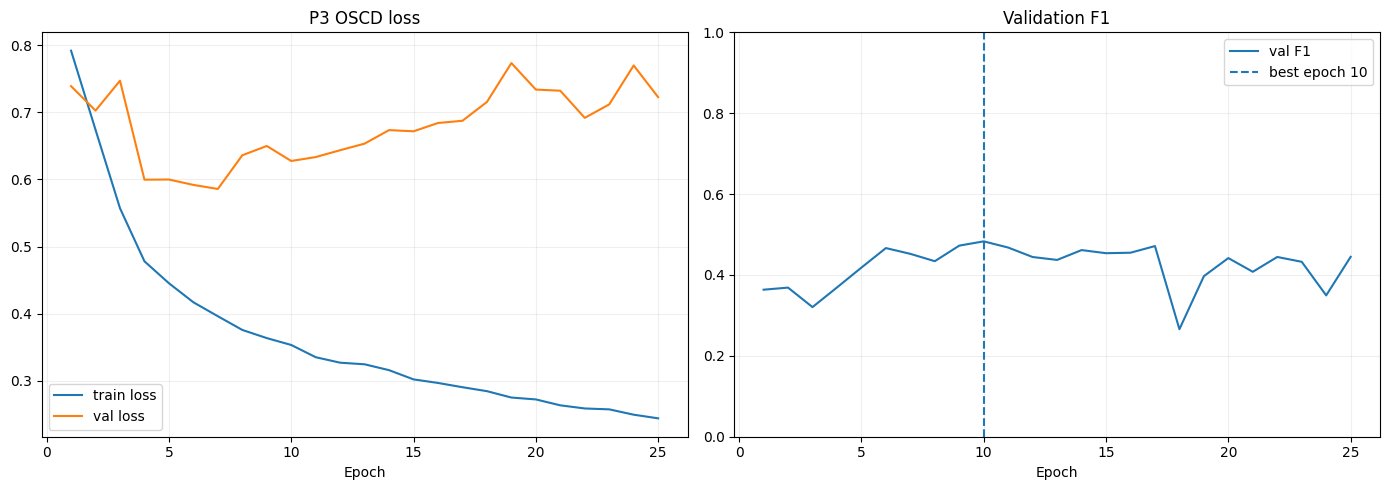

P3 ARTIFACT INTEGRITY
PASS    | geonexus_v3_2_p3_oscd_latest.pth
PASS    | geonexus_v3_2_p3_oscd_best.pth
PASS    | p3_oscd_history.json
PASS    | p3_oscd_config.json
PASS    | p3_geonexus_model.py
PASS    | p3_oscd_training_curves.png
PASS    | geonexus_v3_2_p3_oscd_model.pth
PASS    | geonexus_v3_2_p3_oscd_state_dict.pt
PASS    | SHA256SUMS.json


In [10]:
# ============================================================
# CELL 10 — training curves + integrity summary
# ============================================================

epochs_done=[r["epoch"] for r in history]
train_loss=[r["train_loss"] for r in history]
val_loss=[r["val_loss"] for r in history]
val_f1=[r["val_f1"] for r in history]

fig, ax = plt.subplots(1,2, figsize=(14,5))
ax[0].plot(epochs_done, train_loss, label="train loss")
ax[0].plot(epochs_done, val_loss, label="val loss")
ax[0].set_title("P3 OSCD loss")
ax[0].set_xlabel("Epoch")
ax[0].legend()
ax[0].grid(alpha=0.2)
ax[1].plot(epochs_done, val_f1, label="val F1")
ax[1].axvline(best_epoch, linestyle="--", label=f"best epoch {best_epoch}")
ax[1].set_title("Validation F1")
ax[1].set_xlabel("Epoch")
ax[1].set_ylim(0,1)
ax[1].legend()
ax[1].grid(alpha=0.2)
fig.tight_layout()
fig.savefig(CURVE_PNG, dpi=180, bbox_inches="tight")
plt.show()


def sha256_file(path):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        for chunk in iter(lambda:f.read(8*1024*1024), b""):
            h.update(chunk)
    return h.hexdigest()

artifacts=[LATEST_CKPT,BEST_CKPT,HISTORY_JSON,CONFIG_JSON,MODEL_PY,CURVE_PNG,FINAL_MODEL,FINAL_STATE]
manifest={str(p.name): {"bytes":p.stat().st_size,"sha256":sha256_file(p)} for p in artifacts if p.exists()}
SHA256_JSON.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print("=" * 78)
print("P3 ARTIFACT INTEGRITY")
print("=" * 78)
for p in artifacts+[SHA256_JSON]:
    print(f"{'PASS' if p.exists() else 'MISSING':7s} | {p.name}")


In [11]:
# ============================================================
# CELL 11 — validation threshold sweep (used only on OSCD val)
# ============================================================


val_prob, val_y, _ = collect_scores(val_loader)
thresholds = THRESHOLDS
rows=[]
for t in thresholds:
    m = metrics_from_arrays(val_prob, val_y, float(t))
    rows.append({"threshold":float(t), **m})

best_thr=max(rows, key=lambda r:(r["f1"], -abs(r["threshold"]-0.5)))
VAL_SWEEP_JSON.write_text(json.dumps({"best":best_thr,"rows":rows}, indent=2), encoding="utf-8")

print("=" * 78)
print("OSCD VALIDATION THRESHOLD")
print("=" * 78)
print("Selected threshold:", best_thr["threshold"])
print("Validation F1      :", best_thr["f1"])
print("Validation IoU     :", best_thr["iou"])
print("Threshold is now locked and will be applied unchanged to OSCD test.")


OSCD VALIDATION THRESHOLD
Selected threshold: 0.52
Validation F1      : 0.48309189690288096
Validation IoU     : 0.318471437049018
Threshold is now locked and will be applied unchanged to OSCD test.


In [12]:
# ============================================================
# CELL 12 — final untouched OSCD test evaluation
# ============================================================

TEST_THRESHOLD=float(best_thr["threshold"])
best_val_threshold=float(best_thr["threshold"])

test_prob, test_y, test_indices = collect_scores(test_loader)

pred=test_prob >= TEST_THRESHOLD
yy=test_y > 0.5
tp=int(np.logical_and(pred,yy).sum())
fp=int(np.logical_and(pred,~yy).sum())
fn=int(np.logical_and(~pred,yy).sum())
tn=int(np.logical_and(~pred,~yy).sum())
metrics=binary_metrics_from_counts(tp,fp,fn,tn)
metrics.update({
    "threshold": TEST_THRESHOLD,
    "n_test_patches": int(len(test_y)),
    "test_cities": TEST_CITIES,
    "best_epoch": int(best_epoch),
    "best_val_f1": float(best_val_f1),
    "best_val_threshold": float(best_val_threshold),
    "validation_threshold_locked": float(TEST_THRESHOLD),
})

# Threshold-free AP is computed from the patch-level pixel scores.
try:
    from sklearn.metrics import average_precision_score, cohen_kappa_score
    metrics["average_precision"] = float(average_precision_score(yy.reshape(-1), test_prob.reshape(-1)))
    metrics["kappa"] = float(cohen_kappa_score(yy.reshape(-1).astype(np.uint8), pred.reshape(-1).astype(np.uint8)))
except Exception as exc:
    metrics["average_precision_error"] = str(exc)

TEST_METRICS_JSON.write_text(json.dumps(metrics, indent=2), encoding="utf-8")

# Per-scene metrics are computed from the untouched test labels/predictions.
per_scene=[]
for i,m in enumerate(test_meta):
    p=test_prob[i,0]
    y=test_y[i,0] > 0.5
    pr=p >= TEST_THRESHOLD
    tp=int(np.logical_and(pr,y).sum()); fp=int(np.logical_and(pr,~y).sum())
    fn=int(np.logical_and(~pr,y).sum()); tn=int(np.logical_and(~pr,~y).sum())
    mm=binary_metrics_from_counts(tp,fp,fn,tn)
    per_scene.append({"city":m["city"],"row":m["row"],"col":m["col"],**mm})

with open(TEST_SCENE_CSV,"w",newline="",encoding="utf-8") as f:
    w=csv.DictWriter(f,fieldnames=list(per_scene[0].keys()))
    w.writeheader(); w.writerows(per_scene)

print("=" * 78)
print("FINAL OSCD TEST — P3")
print("=" * 78)
for k,v in metrics.items():
    if k not in {"test_cities"}:
        print(f"{k:24s}: {v}")
print("Per-scene CSV:", TEST_SCENE_CSV)
print("IMPORTANT: the test set was evaluated only after training and threshold locking.")


FINAL OSCD TEST — P3
precision               : 0.5391039763082326
recall                  : 0.4742837171248223
f1                      : 0.5046207624861548
iou                     : 0.33745337402507414
accuracy                : 0.950991695874354
threshold               : 0.52
n_test_patches          : 146
best_epoch              : 10
best_val_f1             : 0.48309189690288096
best_val_threshold      : 0.52
validation_threshold_locked: 0.52
average_precision       : 0.5075800156958316
kappa                   : 0.4789523674100066
Per-scene CSV: /kaggle/working/geonexus_p3_oscd/p3_oscd_test_per_scene.csv
IMPORTANT: the test set was evaluated only after training and threshold locking.


In [13]:
# ============================================================
# CELL 13 — final reproducibility package
# ============================================================

PACKAGE_DIR=RUN_DIR / "p3_release"
if PACKAGE_DIR.exists():
    shutil.rmtree(PACKAGE_DIR)
PACKAGE_DIR.mkdir(parents=True)

# Rebuild the final manifest only after validation and test artifacts exist.
final_artifacts = [
    LATEST_CKPT, BEST_CKPT, HISTORY_JSON, CONFIG_JSON, MODEL_PY, CURVE_PNG,
    VAL_SWEEP_JSON, TEST_METRICS_JSON, TEST_SCENE_CSV, FINAL_MODEL, FINAL_STATE,
]
final_manifest = {}
for p in final_artifacts:
    if p.exists():
        final_manifest[p.name] = {
            "bytes": p.stat().st_size,
            "sha256": sha256_file(p),
        }
SHA256_JSON.write_text(json.dumps(final_manifest, indent=2), encoding="utf-8")

files_to_publish=[
    LATEST_CKPT, BEST_CKPT, HISTORY_JSON, CONFIG_JSON, CURVE_PNG,
    VAL_SWEEP_JSON, TEST_METRICS_JSON, TEST_SCENE_CSV, FINAL_MODEL,
    FINAL_STATE, SHA256_JSON, MODEL_PY,
]
for p in files_to_publish:
    if p.exists():
        shutil.copy2(p, PACKAGE_DIR / p.name)

release_readme = f"""# Geo-Nexus v3.2 — P3 OSCD Supervised Transfer

Stage: P3 supervised optical-only OSCD transfer.
Notebook revision: {RUN_SCHEMA_VERSION}


Training cities: {', '.join(TRAIN_CITIES)}

Validation cities: {', '.join(VAL_CITIES)}

Test cities: {', '.join(TEST_CITIES)}


Patch size: 128
Batch size: 32
Epochs target: 80
Encoder LR: 1e-5
Decoder LR: 1e-4
Decoder: LKA, channels 256/128/64, k=7
Loss: 0.5 BCE + 0.5 Dice with positive-class weight 8.0 and deep-supervision relative weights [1,0.5,0.25]
Gate loss in P3: 0.0 because optical_only mode pins g=1 and freezes the gate
Mode: optical_only (g=1); SAR branch and quality gate frozen; SAR BatchNorm running statistics held in eval mode during P3
Early stopping: best validation F1 over thresholds 0.10–0.90, patience 15
Best validation threshold is saved in the final model metadata and locked before test evaluation

DAPT starting artifact: {Path(DAPT_ENCODER_PATH).name}
OSCD data source: {OSCD_ROOT}

The official OSCD test set is held out until after P3 training and validation threshold selection.
"""
(PACKAGE_DIR/"README.md").write_text(release_readme,encoding="utf-8")

zip_path=RUN_DIR / "GeoNexus_P3_OSCD_Supervised_Transfer_Release.zip"
if zip_path.exists(): zip_path.unlink()
with zipfile.ZipFile(zip_path,"w",compression=zipfile.ZIP_DEFLATED,compresslevel=6) as z:
    for p in sorted(PACKAGE_DIR.rglob("*")):
        if p.is_file():
            z.write(p, arcname=p.relative_to(PACKAGE_DIR))

print("=" * 78)
print("P3 RELEASE PACKAGE READY")
print("=" * 78)
print("Best epoch:", best_epoch)
print("Best validation F1:", best_val_f1)
print("Best validation threshold:", best_val_threshold)
print("OSCD test threshold:", TEST_THRESHOLD)
print("OSCD test F1:", metrics["f1"])
print("OSCD test IoU:", metrics["iou"])
print("Release ZIP:", zip_path)
print("Release directory:", PACKAGE_DIR)


P3 RELEASE PACKAGE READY
Best epoch: 10
Best validation F1: 0.48309189690288096
Best validation threshold: 0.52
OSCD test threshold: 0.52
OSCD test F1: 0.5046207624861548
OSCD test IoU: 0.33745337402507414
Release ZIP: /kaggle/working/geonexus_p3_oscd/GeoNexus_P3_OSCD_Supervised_Transfer_Release.zip
Release directory: /kaggle/working/geonexus_p3_oscd/p3_release


## P3 completion criterion

The P3 stage is complete when:

- DAPT optical and SAR encoder transfer passes with no missing/unexpected state keys.
- OSCD dataset, labels, metadata, sampler, normalization and dataloader gates pass.
- Model forward/gradient smoke tests pass.
- SAR and gate remain frozen during P3; SAR BatchNorm running statistics are held in evaluation mode.
- Training completes or early stopping selects a validated best checkpoint.
- The OSCD validation threshold is locked before untouched test evaluation.
- Final model, state dict, metrics, per-scene CSV, configuration and SHA256 manifest are written to `/kaggle/working/geonexus_p3_oscd/p3_release/`.


## Persistent Kaggle Dataset — P3 artifacts

The `/kaggle/working` directory is temporary. This final cell copies the completed `p3_release` artifacts into an upload folder and publishes them to a private Kaggle Dataset. If the Dataset already exists, a new Dataset version is created; otherwise the Dataset is created. The upload uses Kaggle's official CLI.

After the upload succeeds, the P3 checkpoints, final model, state dict, metrics, threshold sweep, per-scene CSV, configuration, source module, training curve and SHA256 manifest are stored outside the notebook session.


In [15]:
# ============================================================
# FINAL CELL — publish P3 artifacts to a persistent Kaggle Dataset
# Compatible with Kaggle CLI 2.0.2+
# ============================================================

from pathlib import Path
import json
import os
import shutil
import subprocess
import time

# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

KAGGLE_DATASET_ID = "sumit07125/geonexus-p3-oscd-artifacts"
KAGGLE_DIR = RUN_DIR / "kaggle_p3_artifact_upload"

if not RUN_DIR.exists():
    raise FileNotFoundError(f"P3 run directory not found: {RUN_DIR}")

# ------------------------------------------------------------
# 2. Collect the completed P3 release artifacts
# ------------------------------------------------------------

SOURCE_FILES = [
    LATEST_CKPT,
    BEST_CKPT,
    HISTORY_JSON,
    CONFIG_JSON,
    MODEL_PY,
    CURVE_PNG,
    VAL_SWEEP_JSON,
    TEST_METRICS_JSON,
    TEST_SCENE_CSV,
    FINAL_MODEL,
    FINAL_STATE,
    SHA256_JSON,
]

missing = [str(p) for p in SOURCE_FILES if not Path(p).is_file()]

if missing:
    raise FileNotFoundError(
        "Cannot publish P3 artifacts because required files are missing:\n"
        + "\n".join(f"  - {p}" for p in missing)
    )

# ------------------------------------------------------------
# 3. Recreate clean upload directory
# ------------------------------------------------------------

if KAGGLE_DIR.exists():
    shutil.rmtree(KAGGLE_DIR)

KAGGLE_DIR.mkdir(parents=True, exist_ok=True)

for src in SOURCE_FILES:
    src = Path(src)
    shutil.copy2(src, KAGGLE_DIR / src.name)

# README
README_TEXT = f"""# Geo-Nexus v3.2 — P3 OSCD Supervised Transfer Artifacts

Dataset:
{kaggle_dataset_id if False else KAGGLE_DATASET_ID}

Stage:
P3 supervised optical-only OSCD transfer.

Training:
- Epoch target: 80
- Early stopping patience: 15
- Best epoch: {best_epoch}
- Best validation F1: {best_val_f1:.8f}
- Best validation threshold: {best_val_threshold:.2f}

Final untouched OSCD test:
- F1: {metrics["f1"]:.8f}
- IoU: {metrics["iou"]:.8f}
- Precision: {metrics["precision"]:.8f}
- Recall: {metrics["recall"]:.8f}
- Accuracy: {metrics["accuracy"]:.8f}
- Average Precision: {metrics.get("average_precision", float("nan")):.8f}
- Kappa: {metrics.get("kappa", float("nan")):.8f}

Transfer mode:
- Optical-only
- Fusion gate fixed at g=1
- SAR encoder frozen
- Gate loss weight = 0

This Dataset contains the persistent P3 artifacts required for downstream
Geo-Nexus P4 evaluation/adaptation.
"""

(KAGGLE_DIR / "README.md").write_text(README_TEXT, encoding="utf-8")

# ------------------------------------------------------------
# 4. Kaggle metadata
# ------------------------------------------------------------

metadata = {
    "title": "Geo-Nexus P3 OSCD Supervised Transfer Artifacts",
    "id": KAGGLE_DATASET_ID,
    "licenses": [
        {"name": "CC-BY-NC-SA-4.0"}
    ],
    "description": (
        "Geo-Nexus v3.2 P3 OSCD supervised optical-only transfer artifacts. "
        "Contains best/latest checkpoints, final model, state dict, "
        "training history, validation threshold sweep, OSCD test metrics, "
        "per-scene metrics, source code, training curves and SHA256 manifest."
    ),
}

(KAGGLE_DIR / "dataset-metadata.json").write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

# ------------------------------------------------------------
# 5. Kaggle CLI
# ------------------------------------------------------------

kaggle_exe = shutil.which("kaggle")

if kaggle_exe is None:
    raise RuntimeError(
        "Kaggle CLI was not found in this environment."
    )

print("=" * 78)
print("P3 KAGGLE PERSISTENT ARTIFACT PUBLISH")
print("=" * 78)
print("Kaggle CLI :", kaggle_exe)
print("Dataset    :", KAGGLE_DATASET_ID)
print("Upload dir :", KAGGLE_DIR)

# ------------------------------------------------------------
# 6. Helper
# ------------------------------------------------------------

def run_kaggle(*args):
    cmd = [kaggle_exe, *map(str, args)]

    print("\n$", " ".join(cmd))

    result = subprocess.run(
        cmd,
        text=True,
        capture_output=True,
        shell=False,
    )

    if result.stdout:
        print(result.stdout)

    if result.stderr:
        print(result.stderr)

    return result

# ------------------------------------------------------------
# 7. Check whether Dataset already exists
#
# IMPORTANT:
# Kaggle CLI 2.0.2 does NOT support:
#     --format json
#
# Therefore status is called without that argument.
# ------------------------------------------------------------

print("\nChecking whether the Kaggle Dataset already exists...")

status = run_kaggle(
    "datasets",
    "status",
    KAGGLE_DATASET_ID,
)

if status.returncode == 0:
    dataset_exists = True
    print("\nExisting Kaggle Dataset detected.")
else:
    combined = (
        (status.stdout or "") + "\n" +
        (status.stderr or "")
    ).lower()

    not_found_markers = [
        "not found",
        "404",
        "does not exist",
        "dataset not found",
    ]

    if any(marker in combined for marker in not_found_markers):
        dataset_exists = False
        print("\nDataset does not exist yet. A new Dataset will be created.")
    else:
        raise RuntimeError(
            "Kaggle Dataset status check failed for a reason other than "
            "Dataset-not-found.\n\n"
            + (status.stderr or status.stdout or "Unknown Kaggle CLI error.")
        )

# ------------------------------------------------------------
# 8. Create a NEW Dataset or publish a NEW VERSION
# ------------------------------------------------------------

if dataset_exists:

    print("\nPublishing a NEW VERSION of the existing Dataset...")

    publish = run_kaggle(
        "datasets",
        "version",
        "-p",
        KAGGLE_DIR,
        "-m",
        "Geo-Nexus v3.2 P3 final OSCD artifacts",
        "-r",
        "zip",
    )

else:

    print("\nCreating the persistent Kaggle Dataset...")

    publish = run_kaggle(
        "datasets",
        "create",
        "-p",
        KAGGLE_DIR,
        "-t",
        "-r",
        "zip",
    )

if publish.returncode != 0:
    raise RuntimeError(
        "Kaggle Dataset publish command failed."
    )

# ------------------------------------------------------------
# 9. Poll Dataset status
#
# Do NOT use --format json.
# Kaggle CLI 2.0.2 does not support it.
# ------------------------------------------------------------

print("\nWaiting for Kaggle Dataset publication to become visible...")

MAX_CHECKS = 24
WAIT_SECONDS = 15

ready = False

for attempt in range(1, MAX_CHECKS + 1):

    print(
        f"\nStatus check {attempt}/{MAX_CHECKS}..."
    )

    check = run_kaggle(
        "datasets",
        "status",
        KAGGLE_DATASET_ID,
    )

    if check.returncode == 0:
        ready = True
        print("\nKaggle Dataset status command succeeded.")
        break

    print(
        f"Dataset is not visible yet. "
        f"Waiting {WAIT_SECONDS} seconds..."
    )

    time.sleep(WAIT_SECONDS)

if not ready:
    raise RuntimeError(
        "The Kaggle upload command completed, but the Dataset could not "
        "be verified after the polling window.\n"
        f"Dataset: {KAGGLE_DATASET_ID}\n"
        f"Check it manually at: "
        f"https://www.kaggle.com/datasets/{KAGGLE_DATASET_ID}"
    )

# ------------------------------------------------------------
# 10. Final local integrity check
# ------------------------------------------------------------

expected_upload_files = [
    p.name for p in SOURCE_FILES
] + [
    "README.md",
    "dataset-metadata.json",
]

missing_upload = [
    name
    for name in expected_upload_files
    if not (KAGGLE_DIR / name).is_file()
]

if missing_upload:
    raise RuntimeError(
        "Local upload directory is incomplete:\n"
        + "\n".join(f"  - {x}" for x in missing_upload)
    )

print("\n" + "=" * 78)
print("P3 PERSISTENT KAGGLE ARTIFACT: PASS")
print("=" * 78)

print("Dataset :", KAGGLE_DATASET_ID)
print("Files   :", len(expected_upload_files))
print("Upload  :", "SUCCESS")
print("Status  :", "VERIFIED")
print()
print(
    "Persistent Dataset URL:"
)
print(
    f"https://www.kaggle.com/datasets/{KAGGLE_DATASET_ID}"
)
print()
print(
    "SAFE TO TERMINATE THE KAGGLE SESSION."
)
print(
    "The P3 artifacts are now stored in the Kaggle Dataset and are "
    "no longer dependent on /kaggle/working."
)

P3 KAGGLE PERSISTENT ARTIFACT PUBLISH
Kaggle CLI : /usr/local/bin/kaggle
Dataset    : sumit07125/geonexus-p3-oscd-artifacts
Upload dir : /kaggle/working/geonexus_p3_oscd/kaggle_p3_artifact_upload

Checking whether the Kaggle Dataset already exists...

$ /usr/local/bin/kaggle datasets status sumit07125/geonexus-p3-oscd-artifacts
ready

Existing Kaggle Dataset detected.

Publishing a NEW VERSION of the existing Dataset...

$ /usr/local/bin/kaggle datasets version -p /kaggle/working/geonexus_p3_oscd/kaggle_p3_artifact_upload -m Geo-Nexus v3.2 P3 final OSCD artifacts -r zip
Starting upload for file p3_oscd_val_threshold_sweep.json
Upload successful: p3_oscd_val_threshold_sweep.json (17KB)
Starting upload for file p3_geonexus_model.py
Upload successful: p3_geonexus_model.py (8KB)
Starting upload for file p3_oscd_training_curves.png
Upload successful: p3_oscd_training_curves.png (109KB)
Starting upload for file p3_oscd_test_per_scene.csv
Upload successful: p3_oscd_test_per_scene.csv (14KB)
S